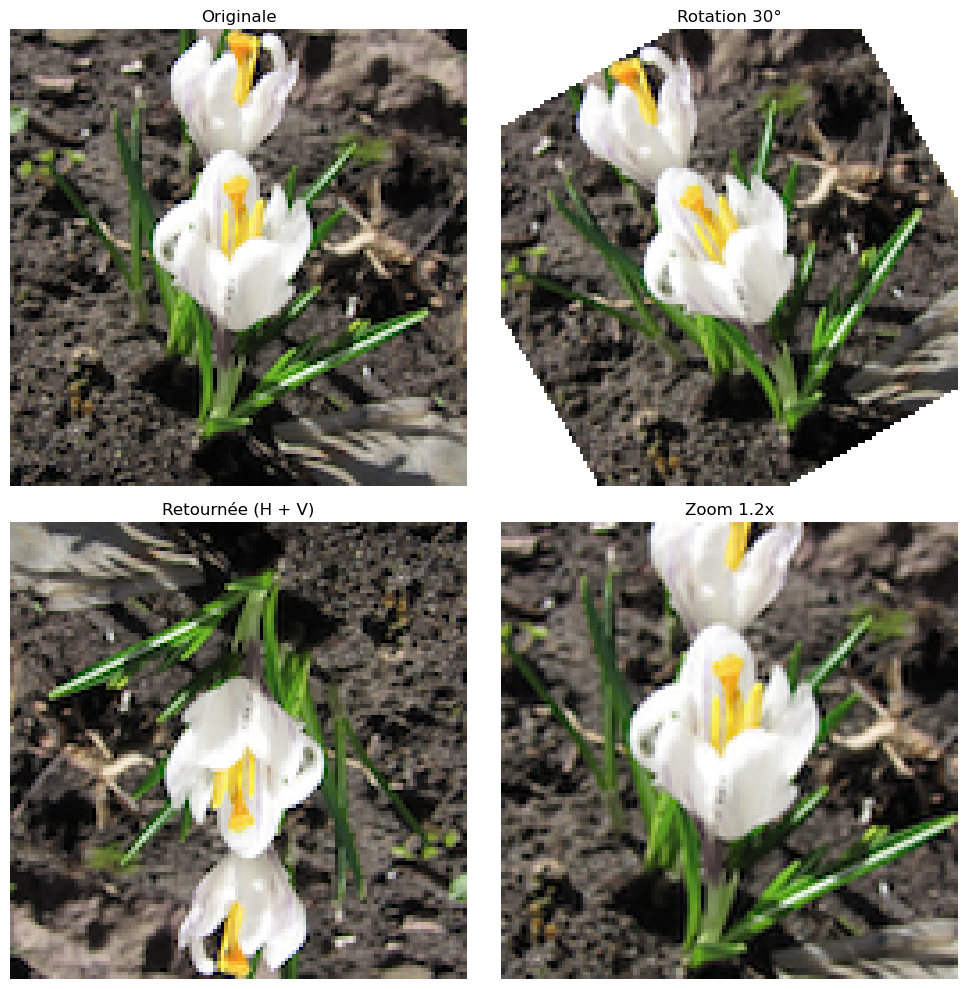

In [4]:
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import numpy as np
from scipy.ndimage import rotate

# 1. Chargement et affichage de l'image originale
image_path = '19_010.png'
original_image = Image.open(image_path)

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(original_image)
plt.title("Originale")
plt.axis('off')

# 2. Rotation de 30 degrés (Complété)
def rotate_image_30_degrees(image):
    # On convertit l'image PIL en tableau numpy pour scipy
    image_np = np.array(image)
    # reshape=False permet de garder les mêmes dimensions d'image
    rotated_np = rotate(image_np, angle=30, reshape=False)
    # On reconvertit en image PIL
    return Image.fromarray(rotated_np)

rotated_image = rotate_image_30_degrees(original_image)
plt.subplot(2, 2, 2)
plt.imshow(rotated_image)
plt.title("Rotation 30°")
plt.axis('off')

# 3. Retournement horizontal (miroir) puis vertical
# ImageOps.mirror fait le flip horizontal, ImageOps.flip fait le flip vertical
flipped_image = ImageOps.mirror(original_image)
flipped_image = ImageOps.flip(flipped_image)

plt.subplot(2, 2, 3)
plt.imshow(flipped_image)
plt.title("Retournée (H + V)")
plt.axis('off')

# 4. Zoom de 1.2x à l'aide de .resize()
# On calcule les nouvelles dimensions, on redimensionne, puis on recadre au centre
width, height = original_image.size
new_width = int(width * 1.2)
new_height = int(height * 1.2)

# Étape A: Redimensionnement global
zoomed_large = original_image.resize((new_width, new_height), Image.Resampling.LANCZOS)

# Étape B: Recadrage (Crop) au centre pour garder la taille d'origine (optionnel mais recommandé)
left = (new_width - width) / 2
top = (new_height - height) / 2
right = (new_width + width) / 2
bottom = (new_height + height) / 2
zoomed_image = zoomed_large.crop((left, top, right, bottom))

plt.subplot(2, 2, 4)
plt.imshow(zoomed_image)
plt.title("Zoom 1.2x")
plt.axis('off')

# Affichage de la grille des résultats
plt.tight_layout()
plt.show()